In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — SETUP: Install libraries + Mount Google Drive
# ══════════════════════════════════════════════════════════════════
!pip install -q transformers datasets accelerate

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

# ── Working directory in Drive ────────────────────────────────────
WORK_DIR = Path("/content/drive/MyDrive/mlvr1_eurlex")
WORK_DIR.mkdir(parents=True, exist_ok=True)   # create folder if missing
print(f"✅ Working directory: {WORK_DIR}")
print(f"   Files already in Drive: {list(WORK_DIR.iterdir()) if WORK_DIR.exists() else 'empty'}")

Mounted at /content/drive
✅ Working directory: /content/drive/MyDrive/mlvr1_eurlex
   Files already in Drive: [PosixPath('/content/drive/MyDrive/mlvr1_eurlex/label2id.pkl'), PosixPath('/content/drive/MyDrive/mlvr1_eurlex/adj_matrix_auto.pt')]


In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — IMPORTS & GLOBAL CONFIG
# ══════════════════════════════════════════════════════════════════
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torch.cuda.amp import autocast, GradScaler
import pickle
import json
from transformers import AutoTokenizer, RobertaModel
from datasets import load_dataset
from sklearn.metrics import f1_score, ndcg_score
from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Global constants ──────────────────────────────────────────────
NUM_LABELS  = 100     # EUR-Lex has 100 label classes
EMBED_DIM   = 768     # RoBERTa hidden size
REDUCED_DIM = 512     # PCA target dimension
BATCH_SIZE  = 256     # for PCA-embed models
EPOCHS      = 15      # training epochs per model

print(f'Embedding: {EMBED_DIM}D → PCA → {REDUCED_DIM}D')
print(f'Labels: {NUM_LABELS}  |  Epochs: {EPOCHS}')

Using device: cuda
Embedding: 768D → PCA → 512D
Labels: 100  |  Epochs: 15


In [3]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — LOAD DATASET + BUILD ADJACENCY MATRIX + LOAD AUG DATA
# ══════════════════════════════════════════════════════════════════

# ── 3A: Load EUR-Lex dataset ──────────────────────────────────────
print("🔄 Loading EUR-Lex dataset from HuggingFace...")
datasets_raw = load_dataset('lex_glue', 'eurlex')

def preprocess(example):
    binary = [0] * NUM_LABELS
    for lab in example['labels']:
        if 0 <= lab < NUM_LABELS:
            binary[lab] = 1
    return {'text': example['text'], 'labels': binary}

dataset = datasets_raw.map(preprocess)
print(f"✅ Dataset loaded:")
print(f"   train={len(dataset['train'])} | val={len(dataset['validation'])} | test={len(dataset['test'])}")

# ── 3B: Build Adjacency Matrix (auto from co-occurrence) ──────────
def build_adj_matrix(label_lists, num_labels, threshold=0.01):
    """
    Builds a normalized label co-occurrence adjacency matrix.
    Works on ANY multi-label dataset.
    """
    co = np.zeros((num_labels, num_labels), dtype=np.float32)
    for labs in label_lists:
        for i in labs:
            for j in labs:
                if 0 <= i < num_labels and 0 <= j < num_labels:
                    co[i][j] += 1.0
    row_sum = co.sum(axis=1, keepdims=True)
    row_sum = np.maximum(row_sum, 1.0)
    adj = co / row_sum
    adj[adj < threshold] = 0.0
    np.fill_diagonal(adj, 1.0)
    return torch.tensor(adj, dtype=torch.float32)

ADJ_CACHE = WORK_DIR / 'adj_matrix_auto.pt'
if ADJ_CACHE.exists():
    adj_matrix = torch.load(ADJ_CACHE, map_location='cpu')
    print(f"✅ Adjacency matrix loaded from Drive cache: {adj_matrix.shape}")
else:
    print("🔄 Building adjacency matrix from label co-occurrence...")
    _label_lists = [ex['labels'] for ex in datasets_raw['train']]
    adj_matrix = build_adj_matrix(_label_lists, NUM_LABELS)
    torch.save(adj_matrix, ADJ_CACHE)
    print(f"✅ Adjacency matrix built & saved to Drive: {adj_matrix.shape}")

# ── 3C: Load augmented data (if available) ────────────────────────
aug_path = WORK_DIR / 'augmented_data.pkl'
if aug_path.exists():
    with open(aug_path, 'rb') as f:
        aug_data = pickle.load(f)
    augmented_texts  = aug_data['texts']
    augmented_labels = aug_data['labels']
    print(f"✅ Augmented data loaded: {len(augmented_texts)} examples")
    HAS_AUG = True
else:
    augmented_texts  = []
    augmented_labels = []
    HAS_AUG = False
    print("ℹ️  No augmented_data.pkl found — Step 5 will train without augmentation")

print(f"\n✅ Cell 3 complete. HAS_AUG={HAS_AUG}")

🔄 Loading EUR-Lex dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

eurlex/train-00000-of-00001.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

eurlex/test-00000-of-00001.parquet:   0%|          | 0.00/24.3M [00:00<?, ?B/s]

eurlex/validation-00000-of-00001.parquet:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/55000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ Dataset loaded:
   train=55000 | val=5000 | test=5000
✅ Adjacency matrix loaded from Drive cache: torch.Size([100, 100])
ℹ️  No augmented_data.pkl found — Step 5 will train without augmentation

✅ Cell 3 complete. HAS_AUG=False


In [4]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 — TOKENIZE + EXTRACT ROBERTA EMBEDDINGS (runs once, saves to Drive)
# ══════════════════════════════════════════════════════════════════

tokenizer = AutoTokenizer.from_pretrained('roberta-base')
print("✅ Tokenizer loaded")

# ── 4A: Tokenize dataset ──────────────────────────────────────────
print("\n🔄 Tokenizing dataset...")
tokenized_datasets = dataset.map(
    lambda x: tokenizer(x['text'], padding='max_length', truncation=True, max_length=512),
    batched=True, remove_columns=['text']
)
tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
print(f"✅ Tokenized: train={len(tokenized_datasets['train'])} | "
      f"val={len(tokenized_datasets['validation'])} | test={len(tokenized_datasets['test'])}")

# ── 4B: Embedding cache paths ─────────────────────────────────────
EMBED_CACHE = {
    'train':      WORK_DIR / 'embeddings_train.pt',
    'validation': WORK_DIR / 'embeddings_val.pt',
    'test':       WORK_DIR / 'embeddings_test.pt',
    'aug':        WORK_DIR / 'embeddings_aug.pt',
}

def extract_embeddings(hf_split, batch_size=64, desc='split'):
    """
    Extract mean-pooled RoBERTa embeddings for an HF dataset split.
    Mean pooling over all non-padding tokens (better than CLS-only).
    """
    roberta = RobertaModel.from_pretrained('roberta-base').to(device)
    roberta.eval()
    loader = DataLoader(hf_split, batch_size=batch_size, shuffle=False, num_workers=2)
    all_embeds = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            with autocast():
                out = roberta(input_ids=ids, attention_mask=mask)
            # Mean pooling
            hidden = out.last_hidden_state                        # (B, L, 768)
            m      = mask.unsqueeze(-1).float()
            emb    = (hidden * m).sum(1) / m.sum(1).clamp(min=1e-9)
            all_embeds.append(emb.cpu().float())
            if (i+1) % 50 == 0:
                print(f"  [{desc}] batch {i+1}/{len(loader)}")
    del roberta
    torch.cuda.empty_cache()
    return torch.cat(all_embeds, dim=0)

def extract_aug_embeddings(texts, labels_list, batch_size=64):
    """
    Extract embeddings for plain-text augmented data.
    """
    roberta = RobertaModel.from_pretrained('roberta-base').to(device)
    roberta.eval()
    all_embeds = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start+batch_size]
        enc = tokenizer(batch_texts, padding='max_length', truncation=True,
                        max_length=512, return_tensors='pt')
        ids  = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)
        with torch.no_grad(), autocast():
            out = roberta(input_ids=ids, attention_mask=mask)
        hidden = out.last_hidden_state
        m      = mask.unsqueeze(-1).float()
        emb    = (hidden * m).sum(1) / m.sum(1).clamp(min=1e-9)
        all_embeds.append(emb.cpu().float())
        if (start // batch_size + 1) % 20 == 0:
            print(f"  [aug] batch {start // batch_size + 1}")
    del roberta
    torch.cuda.empty_cache()
    return torch.cat(all_embeds, dim=0)

# ── 4C: Extract (or load from cache) ─────────────────────────────
print("\n🔄 Extracting RoBERTa embeddings (cached in Drive)...")

for split in ['train', 'validation', 'test']:
    if EMBED_CACHE[split].exists():
        print(f"  ✅ {split} embeddings found in Drive — skipping extraction")
    else:
        print(f"  🔄 Extracting {split} embeddings...")
        emb = extract_embeddings(tokenized_datasets[split], batch_size=64, desc=split)
        torch.save(emb, EMBED_CACHE[split])
        print(f"  ✅ {split} embeddings saved → {EMBED_CACHE[split]}  shape={emb.shape}")

if HAS_AUG:
    if EMBED_CACHE['aug'].exists():
        print(f"  ✅ aug embeddings found in Drive — skipping extraction")
    else:
        print(f"  🔄 Extracting aug embeddings...")
        emb = extract_aug_embeddings(augmented_texts, augmented_labels)
        torch.save(emb, EMBED_CACHE['aug'])
        print(f"  ✅ aug embeddings saved → {EMBED_CACHE['aug']}  shape={emb.shape}")

print("\n✅ Cell 4 complete — all embeddings in Drive")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [validation] batch 50/79
  ✅ validation embeddings saved → /content/drive/MyDrive/mlvr1_eurlex/embeddings_val.pt  shape=torch.Size([5000, 768])
  🔄 Extracting test embeddings...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [test] batch 50/79
  ✅ test embeddings saved → /content/drive/MyDrive/mlvr1_eurlex/embeddings_test.pt  shape=torch.Size([5000, 768])

✅ Cell 4 complete — all embeddings in Drive


In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — PCA: fit on train, transform all splits
# ══════════════════════════════════════════════════════════════════
from sklearn.decomposition import IncrementalPCA
import pickle

PCA_CACHE = WORK_DIR / 'pca_model.pkl'

# Load raw embeddings
print("🔄 Loading raw embeddings from Drive...")
raw_train = torch.load(EMBED_CACHE['train'])      # (N_train, 768)
raw_val   = torch.load(EMBED_CACHE['validation']) # (N_val,   768)
raw_test  = torch.load(EMBED_CACHE['test'])       # (N_test,  768)
print(f"  train={raw_train.shape} | val={raw_val.shape} | test={raw_test.shape}")

if HAS_AUG:
    raw_aug = torch.load(EMBED_CACHE['aug'])
    print(f"  aug={raw_aug.shape}")

# ── Fit or load PCA ───────────────────────────────────────────────
if PCA_CACHE.exists():
    with open(PCA_CACHE, 'rb') as f:
        pca = pickle.load(f)
    print(f"✅ PCA loaded from Drive ({REDUCED_DIM}D)")
else:
    print(f"🔄 Fitting IncrementalPCA ({EMBED_DIM}D → {REDUCED_DIM}D) on train embeddings...")
    pca = IncrementalPCA(n_components=REDUCED_DIM, batch_size=1024)
    pca.fit(raw_train.numpy())
    with open(PCA_CACHE, 'wb') as f:
        pickle.dump(pca, f)
    print(f"✅ PCA fitted & saved to Drive")
    expl = pca.explained_variance_ratio_.sum()
    print(f"   Explained variance: {expl*100:.2f}%")

def pca_transform(raw_tensor):
    """Apply fitted PCA to a raw (N, 768) tensor → (N, REDUCED_DIM) tensor."""
    return torch.tensor(pca.transform(raw_tensor.numpy()), dtype=torch.float32)

print("\n🔄 Transforming all splits with PCA...")
train_emb = pca_transform(raw_train)
val_emb   = pca_transform(raw_val)
test_emb  = pca_transform(raw_test)
if HAS_AUG:
    aug_emb = pca_transform(raw_aug)

print(f"  train_emb={train_emb.shape} | val_emb={val_emb.shape} | test_emb={test_emb.shape}")

# ── Build label tensors ───────────────────────────────────────────
train_labels = torch.tensor(np.array(tokenized_datasets['train']['labels']),    dtype=torch.float32)
val_labels   = torch.tensor(np.array(tokenized_datasets['validation']['labels']),dtype=torch.float32)
test_labels  = torch.tensor(np.array(tokenized_datasets['test']['labels']),     dtype=torch.float32)

if HAS_AUG:
    aug_label_tensors = []
    for labs in augmented_labels:
        binary = [0] * NUM_LABELS
        for l in labs:
            if 0 <= l < NUM_LABELS:
                binary[l] = 1
        aug_label_tensors.append(binary)
    aug_labels = torch.tensor(aug_label_tensors, dtype=torch.float32)

print(f"\n✅ Cell 5 complete — PCA embeddings ready")

🔄 Loading raw embeddings from Drive...
  train=torch.Size([55000, 768]) | val=torch.Size([5000, 768]) | test=torch.Size([5000, 768])
🔄 Fitting IncrementalPCA (768D → 512D) on train embeddings...
✅ PCA fitted & saved to Drive
   Explained variance: 99.61%

🔄 Transforming all splits with PCA...
  train_emb=torch.Size([55000, 512]) | val_emb=torch.Size([5000, 512]) | test_emb=torch.Size([5000, 512])

✅ Cell 5 complete — PCA embeddings ready


In [6]:
# ══════════════════════════════════════════════════════════════════
# CELL 6 — DATASETS & DATALOADERS
# ══════════════════════════════════════════════════════════════════

class EmbedDataset(Dataset):
    def __init__(self, embeds, labels):
        self.embeds = embeds
        self.labels = labels
    def __len__(self):        return len(self.labels)
    def __getitem__(self, i): return {'embed': self.embeds[i], 'labels': self.labels[i]}

orig_train_ds = EmbedDataset(train_emb, train_labels)
val_ds        = EmbedDataset(val_emb,   val_labels)
test_ds       = EmbedDataset(test_emb,  test_labels)

if HAS_AUG:
    aug_ds        = EmbedDataset(aug_emb, aug_labels)
    full_train_ds = ConcatDataset([orig_train_ds, aug_ds])
else:
    full_train_ds = orig_train_ds

def make_loader(ds, batch_size=BATCH_SIZE, shuffle=True):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

orig_train_loader = make_loader(orig_train_ds, shuffle=True)
full_train_loader = make_loader(full_train_ds, shuffle=True)
val_loader        = make_loader(val_ds,        shuffle=False)
test_loader       = make_loader(test_ds,       shuffle=False)

print(f"✅ DataLoaders ready")
print(f"   orig_train : {len(orig_train_ds)} samples  |  full_train: {len(full_train_ds)} samples")
print(f"   val        : {len(val_ds)} samples  |  test: {len(test_ds)} samples")

✅ DataLoaders ready
   orig_train : 55000 samples  |  full_train: 55000 samples
   val        : 5000 samples  |  test: 5000 samples


In [7]:
# ══════════════════════════════════════════════════════════════════
# CELL 7 — MODEL COMPONENTS + MODEL ARCHITECTURES
# ══════════════════════════════════════════════════════════════════

# ── Components ───────────────────────────────────────────────────

class DistributionBalancedLoss(nn.Module):
    """DB Loss with beta=0.999 (prevents extreme weight spread)."""
    def __init__(self, num_labels, beta=0.999):
        super().__init__()
        self.beta = beta
        self.num_labels = num_labels
        self.register_buffer('weights', torch.ones(num_labels))

    def compute_weights(self, train_labels_tensor):
        n_c = train_labels_tensor.sum(dim=0).float() + 1e-8
        self.weights = (1 - self.beta) / (1 - torch.pow(self.beta, n_c))
        self.weights = self.weights / self.weights.sum() * self.num_labels
        print(f'✅ DB Weights — Min: {self.weights.min():.4f}  Max: {self.weights.max():.4f}')

    def forward(self, logits, targets):
        return nn.BCEWithLogitsLoss(
            weight=self.weights.to(logits.device), reduction='mean'
        )(logits, targets.float())


class LabelCorrelationModule(nn.Module):
    """Fixed residual label correlation (probability space, learnable alpha)."""
    def __init__(self, num_labels, adj_matrix):
        super().__init__()
        self.register_buffer('adj', adj_matrix)
        self.alpha = nn.Parameter(torch.tensor(0.1))

    def forward(self, logits):
        corr = torch.matmul(torch.sigmoid(logits), self.adj)   # probability space
        return logits + self.alpha * corr                       # residual addition


class AdaptiveThreshold(nn.Module):
    """Learnable per-label threshold offset."""
    def __init__(self, num_labels):
        super().__init__()
        self.tau = nn.Parameter(torch.zeros(num_labels))

    def forward(self, logits):
        return logits - self.tau.unsqueeze(0)


print("✅ Components defined")

# ── Model Architectures ───────────────────────────────────────────
# All models receive REDUCED_DIM=512 PCA-compressed embeddings

def _make_head(num_labels, in_dim=REDUCED_DIM):
    return nn.Sequential(
        nn.Linear(in_dim, 512),
        nn.LayerNorm(512),
        nn.GELU(),
        nn.Dropout(0.1),
        nn.Linear(512, num_labels)
    )


class BaselineModel(nn.Module):
    def __init__(self, num_labels, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = _make_head(num_labels, in_dim)
    def forward(self, embed): return self.net(embed)


class DBModel(nn.Module):
    def __init__(self, num_labels, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = _make_head(num_labels, in_dim)
    def forward(self, embed): return self.net(embed)


class CorrelationModel(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = _make_head(num_labels, in_dim)
        self.correlation = LabelCorrelationModule(num_labels, adj_matrix)
    def forward(self, embed):
        return self.correlation(self.net(embed))


class AdaptiveModel(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net         = _make_head(num_labels, in_dim)
        self.correlation = LabelCorrelationModule(num_labels, adj_matrix)
        self.adaptive    = AdaptiveThreshold(num_labels)
    def forward(self, embed):
        return self.adaptive(self.correlation(self.net(embed)))


class FullC2DBT(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net         = _make_head(num_labels, in_dim)
        self.correlation = LabelCorrelationModule(num_labels, adj_matrix)
        self.adaptive    = AdaptiveThreshold(num_labels)
    def forward(self, embed):
        return self.adaptive(self.correlation(self.net(embed)))


# Full fine-tuned RoBERTa model (Step 6)
class CorrelationModelFull(nn.Module):
    """
    Full end-to-end: RoBERTa encoder + correlation + adaptive threshold.
    Slower but highest accuracy.
    """
    def __init__(self, num_labels, adj_matrix, encoder_name='roberta-base'):
        super().__init__()
        self.encoder     = RobertaModel.from_pretrained(encoder_name)
        self.head        = nn.Sequential(
            nn.Linear(768, 512), nn.LayerNorm(512), nn.GELU(),
            nn.Dropout(0.1), nn.Linear(512, num_labels)
        )
        self.correlation = LabelCorrelationModule(num_labels, adj_matrix)
        self.adaptive    = AdaptiveThreshold(num_labels)

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        mask   = attention_mask.unsqueeze(-1).float()
        hidden = out.last_hidden_state
        emb    = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        logits = self.head(emb)
        return self.adaptive(self.correlation(logits))


adj = adj_matrix.to(device)
print("✅ All model architectures defined")
print(f"   adj_matrix on {adj.device}: {adj.shape}")

✅ Components defined
✅ All model architectures defined
   adj_matrix on cuda:0: torch.Size([100, 100])


In [8]:
# ══════════════════════════════════════════════════════════════════
# CELL 8 — METRICS + TRAIN + EVALUATE HELPERS
# ══════════════════════════════════════════════════════════════════

# ── Metrics ───────────────────────────────────────────────────────
def precision_at_k(y_true, y_scores, k):
    res = []
    for i in range(y_true.shape[0]):
        top = np.argsort(y_scores[i])[::-1][:k]
        res.append(y_true[i][top].sum() / k)
    return float(np.mean(res))

def ndcg_at_k(y_true, y_scores, k):
    return float(np.mean([ndcg_score([y_true[i]], [y_scores[i]], k=k)
                           for i in range(len(y_true))]))

def compute_all_metrics(all_labels, all_probs):
    preds = (all_probs > 0.5).astype(float)
    return {
        'Micro-F1': f1_score(all_labels, preds, average='micro',  zero_division=0),
        'Macro-F1': f1_score(all_labels, preds, average='macro',  zero_division=0),
        'P@1':  precision_at_k(all_labels, all_probs, 1),
        'P@3':  precision_at_k(all_labels, all_probs, 3),
        'P@5':  precision_at_k(all_labels, all_probs, 5),
        'NDCG@1': ndcg_at_k(all_labels, all_probs, 1),
        'NDCG@3': ndcg_at_k(all_labels, all_probs, 3),
        'NDCG@5': ndcg_at_k(all_labels, all_probs, 5),
    }

METRIC_KEYS = ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']

# ── Training function (PCA-embed models) ─────────────────────────
def train_model(model, train_loader, val_loader, optimizer, criterion=None,
                epochs=EPOCHS, model_name='model', label_smooth=0.05):
    """
    Trains a PCA-embedding model.
    Saves best checkpoint to Drive automatically.
    """
    history  = {k: [] for k in METRIC_KEYS}
    scaler   = GradScaler()
    scheduler= torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    best_mf1 = 0.0
    best_path= str(WORK_DIR / f'{model_name}_best.pth')

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            embed  = batch['embed'].to(device)
            labels = batch['labels'].to(device).float()
            if label_smooth > 0:
                labels = labels * (1 - label_smooth) + label_smooth / 2
            optimizer.zero_grad()
            with autocast():
                logits = model(embed)
                loss   = criterion(logits, labels) if criterion else nn.BCEWithLogitsLoss()(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        scheduler.step()
        lr_now = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}  LR: {lr_now:.2e}')

        # ── Validate ──
        model.eval()
        all_probs, all_lbls = [], []
        with torch.no_grad():
            for batch in val_loader:
                embed  = batch['embed'].to(device)
                labels = batch['labels']
                with autocast():
                    logits = model(embed)
                all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
                all_lbls.append(labels.cpu().numpy())

        all_probs = np.vstack(all_probs)
        all_lbls  = np.vstack(all_lbls)
        m = compute_all_metrics(all_lbls, all_probs)
        for k, v in m.items(): history[k].append(v)

        print(f'  Val Micro-F1: {m["Micro-F1"]:.4f} | Macro-F1: {m["Macro-F1"]:.4f} '
              f'| P@1: {m["P@1"]:.4f} | P@3: {m["P@3"]:.4f} | P@5: {m["P@5"]:.4f} '
              f'| NDCG@1: {m["NDCG@1"]:.4f} | NDCG@3: {m["NDCG@3"]:.4f} | NDCG@5: {m["NDCG@5"]:.4f}')

        if m['Micro-F1'] > best_mf1:
            best_mf1 = m['Micro-F1']
            torch.save(model.state_dict(), best_path)
            print(f'  💾 Best checkpoint saved to Drive  Micro-F1={best_mf1:.4f}')

    print(f'\n✅ Done. Best Val Micro-F1: {best_mf1:.4f}')
    return history


# ── Training function (Full fine-tuned RoBERTa) ───────────────────
def train_model_full(model, train_loader, val_loader, optimizer, criterion=None,
                     epochs=EPOCHS, model_name='full_ft', label_smooth=0.05):
    """
    Trains CorrelationModelFull (end-to-end RoBERTa).
    Expects batches with input_ids + attention_mask.
    """
    history  = {k: [] for k in METRIC_KEYS}
    scaler   = GradScaler()
    scheduler= torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    best_mf1 = 0.0
    best_path= str(WORK_DIR / f'{model_name}_best.pth')

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device).float()
            if label_smooth > 0:
                labels = labels * (1 - label_smooth) + label_smooth / 2
            optimizer.zero_grad()
            with autocast():
                logits = model(input_ids, attention_mask)
                loss   = criterion(logits, labels) if criterion else nn.BCEWithLogitsLoss()(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        scheduler.step()
        lr_now = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}  LR: {lr_now:.2e}')

        model.eval()
        all_probs, all_lbls = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels']
                with autocast():
                    logits = model(input_ids, attention_mask)
                all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
                all_lbls.append(labels.cpu().numpy())

        all_probs = np.vstack(all_probs)
        all_lbls  = np.vstack(all_lbls)
        m = compute_all_metrics(all_lbls, all_probs)
        for k, v in m.items(): history[k].append(v)

        print(f'  Val Micro-F1: {m["Micro-F1"]:.4f} | Macro-F1: {m["Macro-F1"]:.4f} '
              f'| P@1: {m["P@1"]:.4f} | P@3: {m["P@3"]:.4f} | NDCG@3: {m["NDCG@3"]:.4f}')

        if m['Micro-F1'] > best_mf1:
            best_mf1 = m['Micro-F1']
            torch.save(model.state_dict(), best_path)
            print(f'  💾 Best checkpoint saved to Drive  Micro-F1={best_mf1:.4f}')

    print(f'\n✅ Done. Best Val Micro-F1: {best_mf1:.4f}')
    return history


print("✅ Metrics + training functions defined")

✅ Metrics + training functions defined


In [9]:
# ══════════════════════════════════════════════════════════════════
# CELL 9 — ABLATION TRAINING (Steps 1–5) + SAVE HISTORIES TO DRIVE
# ══════════════════════════════════════════════════════════════════

# DB criterion (needed for Steps 2 & 5)
db_criterion = DistributionBalancedLoss(NUM_LABELS)
db_criterion.compute_weights(train_labels)
db_criterion = db_criterion.to(device)

# ══ STEP 1: Baseline ══════════════════════════════════════════════
print("\n" + "═"*60)
print("🔄 Step 1: Baseline")
print("═"*60)
baseline_model = BaselineModel(NUM_LABELS).to(device)
opt = torch.optim.AdamW(baseline_model.parameters(), lr=1e-3, weight_decay=1e-4)
baseline_hist = train_model(baseline_model, orig_train_loader, val_loader,
                            opt, epochs=EPOCHS, model_name='baseline_pca')

# ══ STEP 2: DB Loss ═══════════════════════════════════════════════
print("\n" + "═"*60)
print("🔄 Step 2: DB Loss")
print("═"*60)
db_model = DBModel(NUM_LABELS).to(device)
opt = torch.optim.AdamW(db_model.parameters(), lr=1e-3, weight_decay=1e-4)
db_hist = train_model(db_model, orig_train_loader, val_loader,
                      opt, criterion=db_criterion, epochs=EPOCHS, model_name='db_pca')

# ══ STEP 3: Correlation (fixed residual) ══════════════════════════
print("\n" + "═"*60)
print("🔄 Step 3: Correlation (fixed residual)")
print("═"*60)
corr_model = CorrelationModel(NUM_LABELS, adj.cpu()).to(device)
opt = torch.optim.AdamW(corr_model.parameters(), lr=1e-3, weight_decay=1e-4)
corr_hist = train_model(corr_model, orig_train_loader, val_loader,
                        opt, criterion=db_criterion, epochs=EPOCHS, model_name='corr_pca')

# ══ STEP 4: Adaptive Threshold ════════════════════════════════════
print("\n" + "═"*60)
print("🔄 Step 4: Adaptive Threshold")
print("═"*60)
adapt_model = AdaptiveModel(NUM_LABELS, adj.cpu()).to(device)
opt = torch.optim.AdamW(adapt_model.parameters(), lr=1e-3, weight_decay=1e-4)
adapt_hist = train_model(adapt_model, orig_train_loader, val_loader,
                         opt, criterion=db_criterion, epochs=EPOCHS, model_name='adapt_pca')

# ══ STEP 5: Full C²DB-T + LLM Augmentation ════════════════════════
print("\n" + "═"*60)
print("🔄 Step 5: Full C²DB-T + LLM Augmentation")
print("═"*60)
full_model = FullC2DBT(NUM_LABELS, adj.cpu()).to(device)
opt = torch.optim.AdamW(full_model.parameters(), lr=1e-3, weight_decay=1e-4)
# Use augmented data if available, else fall back to orig_train_loader
full_hist = train_model(full_model,
                        full_train_loader if HAS_AUG else orig_train_loader,
                        val_loader,
                        opt, criterion=db_criterion, epochs=EPOCHS, model_name='full_pca')

# ── Save all val histories to Drive ──────────────────────────────
all_hists = {
    'Baseline':          baseline_hist,
    'DB Loss':           db_hist,
    'Correlation':       corr_hist,
    'Adaptive':          adapt_hist,
    'Full C2DB-T+LLM':  full_hist,
}
hist_save_path = WORK_DIR / 'val_histories_steps1_5.json'
with open(hist_save_path, 'w') as f:
    json.dump(all_hists, f, indent=2)
print(f"\n✅ Val histories (Steps 1-5) saved → {hist_save_path}")

✅ DB Weights — Min: 0.4778  Max: 2.7734

════════════════════════════════════════════════════════════
🔄 Step 1: Baseline
════════════════════════════════════════════════════════════
Epoch 1/15 — Loss: 0.1983  LR: 9.89e-04
  Val Micro-F1: 0.6454 | Macro-F1: 0.3067 | P@1: 0.8734 | P@3: 0.7657 | P@5: 0.6360 | NDCG@1: 0.8733 | NDCG@3: 0.8021 | NDCG@5: 0.7804
  💾 Best checkpoint saved to Drive  Micro-F1=0.6454
Epoch 2/15 — Loss: 0.1663  LR: 9.57e-04
  Val Micro-F1: 0.6768 | Macro-F1: 0.3875 | P@1: 0.9042 | P@3: 0.7889 | P@5: 0.6576 | NDCG@1: 0.9042 | NDCG@3: 0.8270 | NDCG@5: 0.8063
  💾 Best checkpoint saved to Drive  Micro-F1=0.6768
Epoch 3/15 — Loss: 0.1620  LR: 9.05e-04
  Val Micro-F1: 0.6868 | Macro-F1: 0.4134 | P@1: 0.9126 | P@3: 0.7995 | P@5: 0.6673 | NDCG@1: 0.9127 | NDCG@3: 0.8381 | NDCG@5: 0.8187
  💾 Best checkpoint saved to Drive  Micro-F1=0.6868
Epoch 4/15 — Loss: 0.1594  LR: 8.36e-04
  Val Micro-F1: 0.6938 | Macro-F1: 0.4452 | P@1: 0.9120 | P@3: 0.7891 | P@5: 0.6641 | NDCG@1: 0.9

In [11]:
# ══════════════════════════════════════════════════════════════════
# CELL 10 — STEP 6: FULL FINE-TUNED ROBERTA (end-to-end)
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("🔄 Step 6: Corr Full FT (end-to-end RoBERTa fine-tune)")
print("═"*60)

# Token-level DataLoaders (input_ids + attention_mask)
ft_train_loader = DataLoader(
    tokenized_datasets['train'], batch_size=8, shuffle=True, num_workers=2
)
ft_val_loader = DataLoader(
    tokenized_datasets['validation'], batch_size=8, shuffle=False, num_workers=2
)

full_ft_model = CorrelationModelFull(NUM_LABELS, adj.cpu()).to(device)

# Differential LR: encoder gets 10x smaller LR
opt = torch.optim.AdamW([
    {'params': full_ft_model.encoder.parameters(), 'lr': 1e-5},
    {'params': list(full_ft_model.head.parameters()) +
               list(full_ft_model.correlation.parameters()) +
               list(full_ft_model.adaptive.parameters()),
     'lr': 1e-4}
], weight_decay=1e-4)

full_ft_hist = train_model_full(
    full_ft_model, ft_train_loader, ft_val_loader,
    opt, criterion=db_criterion, epochs=6, model_name='corr_full_ft'
)

# Save Step 6 history
ft_hist_path = WORK_DIR / 'val_history_step6_full_ft.json'
with open(ft_hist_path, 'w') as f:
    json.dump({'Corr Full FT': full_ft_hist}, f, indent=2)
print(f"✅ Step 6 val history saved → {ft_hist_path}")


════════════════════════════════════════════════════════════
🔄 Step 6: Corr Full FT (end-to-end RoBERTa fine-tune)
════════════════════════════════════════════════════════════


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/6 — Loss: 0.1541  LR: 1.00e-05
  Val Micro-F1: 0.7402 | Macro-F1: 0.5377 | P@1: 0.9440 | P@3: 0.8372 | NDCG@3: 0.8755
  💾 Best checkpoint saved to Drive  Micro-F1=0.7402
Epoch 2/6 — Loss: 0.1418  LR: 1.00e-05
  Val Micro-F1: 0.7605 | Macro-F1: 0.5951 | P@1: 0.9326 | P@3: 0.8507 | NDCG@3: 0.8848
  💾 Best checkpoint saved to Drive  Micro-F1=0.7605
Epoch 3/6 — Loss: 0.1386  LR: 1.00e-05
  Val Micro-F1: 0.7683 | Macro-F1: 0.6187 | P@1: 0.9318 | P@3: 0.8563 | NDCG@3: 0.8893
  💾 Best checkpoint saved to Drive  Micro-F1=0.7683
Epoch 4/6 — Loss: 0.1364  LR: 1.00e-05
  Val Micro-F1: 0.7710 | Macro-F1: 0.6296 | P@1: 0.9502 | P@3: 0.8552 | NDCG@3: 0.8917
  💾 Best checkpoint saved to Drive  Micro-F1=0.7710
Epoch 5/6 — Loss: 0.1346  LR: 1.00e-05
  Val Micro-F1: 0.7759 | Macro-F1: 0.6424 | P@1: 0.9438 | P@3: 0.8594 | NDCG@3: 0.8942
  💾 Best checkpoint saved to Drive  Micro-F1=0.7759
Epoch 6/6 — Loss: 0.1331  LR: 1.00e-05
  Val Micro-F1: 0.7755 | Macro-F1: 0.6486 | P@1: 0.9478 | P@3: 0.8609 |

In [12]:
# ══════════════════════════════════════════════════════════════════
# CELL 11 — PER-LABEL THRESHOLD TUNING (all 6 models)
# ══════════════════════════════════════════════════════════════════

def find_best_thresholds(model, loader, num_labels=NUM_LABELS, is_full_ft=False):
    """Find per-label thresholds that maximize F1 on validation set."""
    model.eval()
    all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in loader:
            if is_full_ft:
                ids   = batch['input_ids'].to(device)
                mask  = batch['attention_mask'].to(device)
                labels= batch['labels']
                with autocast(): logits = model(ids, mask)
            else:
                embed = batch['embed'].to(device)
                labels= batch['labels']
                with autocast(): logits = model(embed)
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(labels.numpy())

    all_probs = np.vstack(all_probs)
    all_lbls  = np.vstack(all_lbls)

    best_thresh = np.zeros(num_labels)
    print("🔧 Finding per-label thresholds...")
    for i in range(num_labels):
        max_f1, best_t = 0, 0.5
        for t in np.arange(0.1, 0.95, 0.02):
            pred = (all_probs[:, i] >= t).astype(int)
            f1   = f1_score(all_lbls[:, i], pred, zero_division=0)
            if f1 > max_f1: max_f1, best_t = f1, t
        best_thresh[i] = best_t

    preds_tuned = np.zeros_like(all_probs)
    for i in range(num_labels):
        preds_tuned[:, i] = (all_probs[:, i] >= best_thresh[i]).astype(float)
    m = compute_all_metrics(all_lbls, preds_tuned)
    return best_thresh, m


print("🔄 Threshold tuning — all 6 models...")
tuned_results = {}
thresholds    = {}

steps_pca = [
    ('Baseline',         baseline_model, val_loader),
    ('DB Loss',          db_model,       val_loader),
    ('Correlation',      corr_model,     val_loader),
    ('Adaptive',         adapt_model,    val_loader),
    ('Full C2DB-T+LLM',  full_model,     val_loader),
]

for name, model, loader in steps_pca:
    print(f"\n  Tuning: {name}")
    thresh, m = find_best_thresholds(model, loader, is_full_ft=False)
    thresholds[name]    = thresh.tolist()
    tuned_results[name] = m
    print(f"  Micro-F1: {m['Micro-F1']:.4f} | Macro-F1: {m['Macro-F1']:.4f} | P@1: {m['P@1']:.4f}")

print(f"\n  Tuning: Corr Full FT")
thresh_ft, m_ft = find_best_thresholds(full_ft_model, ft_val_loader, is_full_ft=True)
thresholds['Corr Full FT']    = thresh_ft.tolist()
tuned_results['Corr Full FT'] = m_ft
print(f"  Micro-F1: {m_ft['Micro-F1']:.4f} | Macro-F1: {m_ft['Macro-F1']:.4f} | P@1: {m_ft['P@1']:.4f}")

# ── Save to Drive ─────────────────────────────────────────────────
tuned_save_path = WORK_DIR / 'tuned_val_results.json'
thresh_save_path= WORK_DIR / 'per_label_thresholds.json'
with open(tuned_save_path, 'w') as f:  json.dump(tuned_results, f, indent=2)
with open(thresh_save_path, 'w') as f: json.dump(thresholds,    f, indent=2)
print(f"\n✅ Tuned val results saved → {tuned_save_path}")
print(f"✅ Per-label thresholds saved → {thresh_save_path}")

🔄 Threshold tuning — all 6 models...

  Tuning: Baseline
🔧 Finding per-label thresholds...
  Micro-F1: 0.7288 | Macro-F1: 0.5987 | P@1: 0.7632

  Tuning: DB Loss
🔧 Finding per-label thresholds...
  Micro-F1: 0.7314 | Macro-F1: 0.6084 | P@1: 0.8042

  Tuning: Correlation
🔧 Finding per-label thresholds...
  Micro-F1: 0.7297 | Macro-F1: 0.6092 | P@1: 0.8004

  Tuning: Adaptive
🔧 Finding per-label thresholds...
  Micro-F1: 0.7336 | Macro-F1: 0.6106 | P@1: 0.7996

  Tuning: Full C2DB-T+LLM
🔧 Finding per-label thresholds...
  Micro-F1: 0.7335 | Macro-F1: 0.6087 | P@1: 0.8094

  Tuning: Corr Full FT
🔧 Finding per-label thresholds...
  Micro-F1: 0.7887 | Macro-F1: 0.6864 | P@1: 0.8756

✅ Tuned val results saved → /content/drive/MyDrive/mlvr1_eurlex/tuned_val_results.json
✅ Per-label thresholds saved → /content/drive/MyDrive/mlvr1_eurlex/per_label_thresholds.json


In [13]:
# ══════════════════════════════════════════════════════════════════
# CELL 12 — TEST SET EVALUATION (all 6 models)
# ══════════════════════════════════════════════════════════════════

ft_test_loader = DataLoader(
    tokenized_datasets['test'], batch_size=8, shuffle=False, num_workers=2
)

def eval_on_test(model, loader, thresh, label='model', is_full_ft=False):
    """Evaluate model on test set using tuned thresholds."""
    model.eval()
    all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in loader:
            if is_full_ft:
                ids   = batch['input_ids'].to(device)
                mask  = batch['attention_mask'].to(device)
                labels= batch['labels']
                with autocast(): logits = model(ids, mask)
            else:
                embed = batch['embed'].to(device)
                labels= batch['labels']
                with autocast(): logits = model(embed)
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(labels.numpy())

    all_probs = np.vstack(all_probs)
    all_lbls  = np.vstack(all_lbls)

    thresh_arr = np.array(thresh)
    preds = np.zeros_like(all_probs)
    for i in range(all_probs.shape[1]):
        preds[:, i] = (all_probs[:, i] >= thresh_arr[i]).astype(float)

    m = compute_all_metrics(all_lbls, preds)
    print(f'{label:24}  Micro-F1:{m["Micro-F1"]:.4f} | Macro-F1:{m["Macro-F1"]:.4f} '
          f'| P@1:{m["P@1"]:.4f} | P@3:{m["P@3"]:.4f} | NDCG@3:{m["NDCG@3"]:.4f}')
    return m

print("🔄 Test set evaluation — all 6 models...")
test_results = {}

steps_test = [
    ('Baseline',         baseline_model, test_loader, False),
    ('DB Loss',          db_model,       test_loader, False),
    ('Correlation',      corr_model,     test_loader, False),
    ('Adaptive',         adapt_model,    test_loader, False),
    ('Full C2DB-T+LLM',  full_model,     test_loader, False),
    ('Corr Full FT',     full_ft_model,  ft_test_loader, True),
]

for name, model, loader, is_ft in steps_test:
    test_results[name] = eval_on_test(
        model, loader, thresholds[name], label=name, is_full_ft=is_ft
    )

# ── Save test results to Drive ────────────────────────────────────
test_save_path = WORK_DIR / 'test_results.json'
with open(test_save_path, 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"\n✅ Test results saved → {test_save_path}")

🔄 Test set evaluation — all 6 models...
Baseline                  Micro-F1:0.6502 | Macro-F1:0.5222 | P@1:0.6312 | P@3:0.6415 | NDCG@3:0.6598
DB Loss                   Micro-F1:0.6527 | Macro-F1:0.5177 | P@1:0.7136 | P@3:0.6639 | NDCG@3:0.6644
Correlation               Micro-F1:0.6555 | Macro-F1:0.5281 | P@1:0.7314 | P@3:0.6728 | NDCG@3:0.6767
Adaptive                  Micro-F1:0.6647 | Macro-F1:0.5313 | P@1:0.7154 | P@3:0.6772 | NDCG@3:0.6744
Full C2DB-T+LLM           Micro-F1:0.6644 | Macro-F1:0.5228 | P@1:0.7614 | P@3:0.6903 | NDCG@3:0.6869
Corr Full FT              Micro-F1:0.7288 | Macro-F1:0.6030 | P@1:0.8278 | P@3:0.7571 | NDCG@3:0.7542

✅ Test results saved → /content/drive/MyDrive/mlvr1_eurlex/test_results.json


In [14]:
# ══════════════════════════════════════════════════════════════════
# CELL 13 — PRINT RESULT TABLES (Val vs Test)
# ══════════════════════════════════════════════════════════════════

STEPS_ALL = ['Baseline', 'DB Loss', 'Correlation', 'Adaptive', 'Full C2DB-T+LLM', 'Corr Full FT']

header = "{:<24}".format("Model") + "".join("{:>10}".format(k) for k in METRIC_KEYS)
sep    = "=" * len(header)

# ── Test Results ──────────────────────────────────────────────────
print("\n" + sep)
print("TEST SET RESULTS  (best checkpoint + tuned thresholds)")
print(sep)
print(header)
print("-" * len(header))
for step in STEPS_ALL:
    if step in test_results:
        marker = "  ← BEST" if step == "Corr Full FT" else ""
        row = "{:<24}".format(step) + "".join("{:>10.4f}".format(test_results[step][k]) for k in METRIC_KEYS)
        print(row + marker)
print(sep)

# ── Val vs Test Comparison ────────────────────────────────────────
print("\n" + sep)
print("VALIDATION vs TEST COMPARISON  (threshold tuned)")
print(sep)
print("{:<24}  {:>14}  {:>14}  {:>8}".format("Model", "Val Micro-F1", "Test Micro-F1", "Delta"))
print("-" * 66)
for step in STEPS_ALL:
    val_mf1  = tuned_results.get(step, {}).get('Micro-F1', float('nan'))
    test_mf1 = test_results.get(step,  {}).get('Micro-F1', float('nan'))
    delta    = test_mf1 - val_mf1
    flag     = "  <-- overfit" if delta < -0.02 else ""
    print("{:<24}  {:>14.4f}  {:>14.4f}  {:>+8.4f}{}".format(step, val_mf1, test_mf1, delta, flag))
print(sep)

# ── Improvement Summary ───────────────────────────────────────────
print("\n📊 IMPROVEMENT SUMMARY")
baseline_mf1 = tuned_results.get('Baseline', {}).get('Micro-F1', 0)
for step in STEPS_ALL[1:]:
    mf1 = tuned_results.get(step, {}).get('Micro-F1', 0)
    if baseline_mf1 > 0:
        pct = ((mf1 - baseline_mf1) / baseline_mf1) * 100
        print(f"  {step:<24}: {mf1:.4f}  ({pct:+.2f}% vs Baseline)")


TEST SET RESULTS  (best checkpoint + tuned thresholds)
Model                     Micro-F1  Macro-F1       P@1       P@3       P@5    NDCG@1    NDCG@3    NDCG@5
--------------------------------------------------------------------------------------------------------
Baseline                    0.6502    0.5222    0.6312    0.6415    0.5846    0.6672    0.6598    0.6663
DB Loss                     0.6527    0.5177    0.7136    0.6639    0.5828    0.6752    0.6644    0.6673
Correlation                 0.6555    0.5281    0.7314    0.6728    0.5856    0.6844    0.6767    0.6735
Adaptive                    0.6647    0.5313    0.7154    0.6772    0.5925    0.6765    0.6744    0.6768
Full C2DB-T+LLM             0.6644    0.5228    0.7614    0.6903    0.5896    0.6978    0.6869    0.6792
Corr Full FT                0.7288    0.6030    0.8278    0.7571    0.6427    0.7628    0.7542    0.7416  ← BEST

VALIDATION vs TEST COMPARISON  (threshold tuned)
Model                       Val Micro-F1   Tes

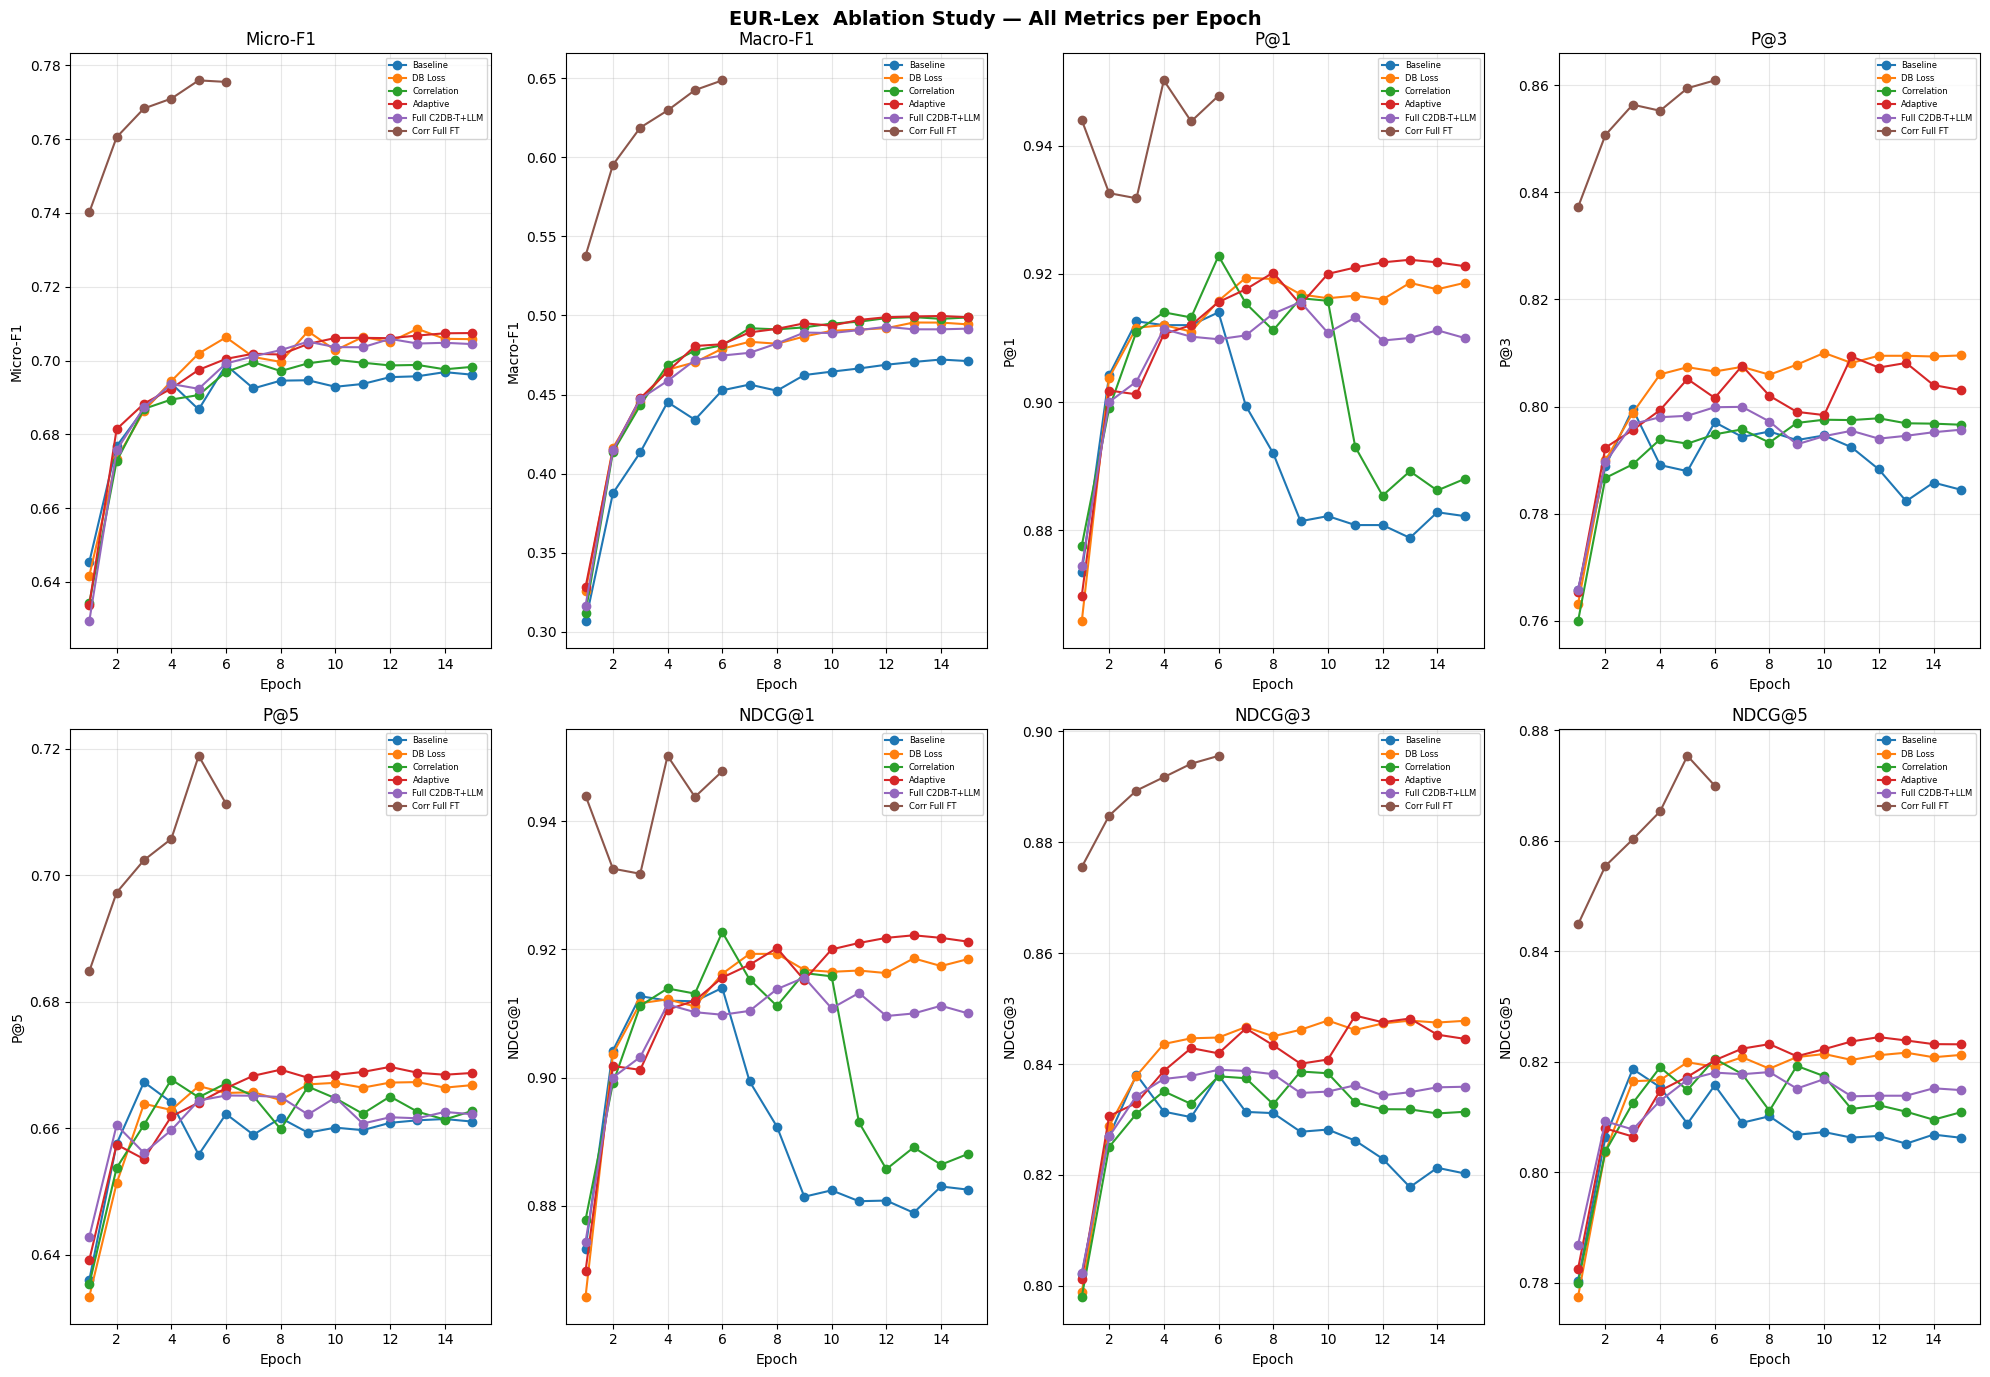

✅ Figure 1 saved: training_curves_all.png


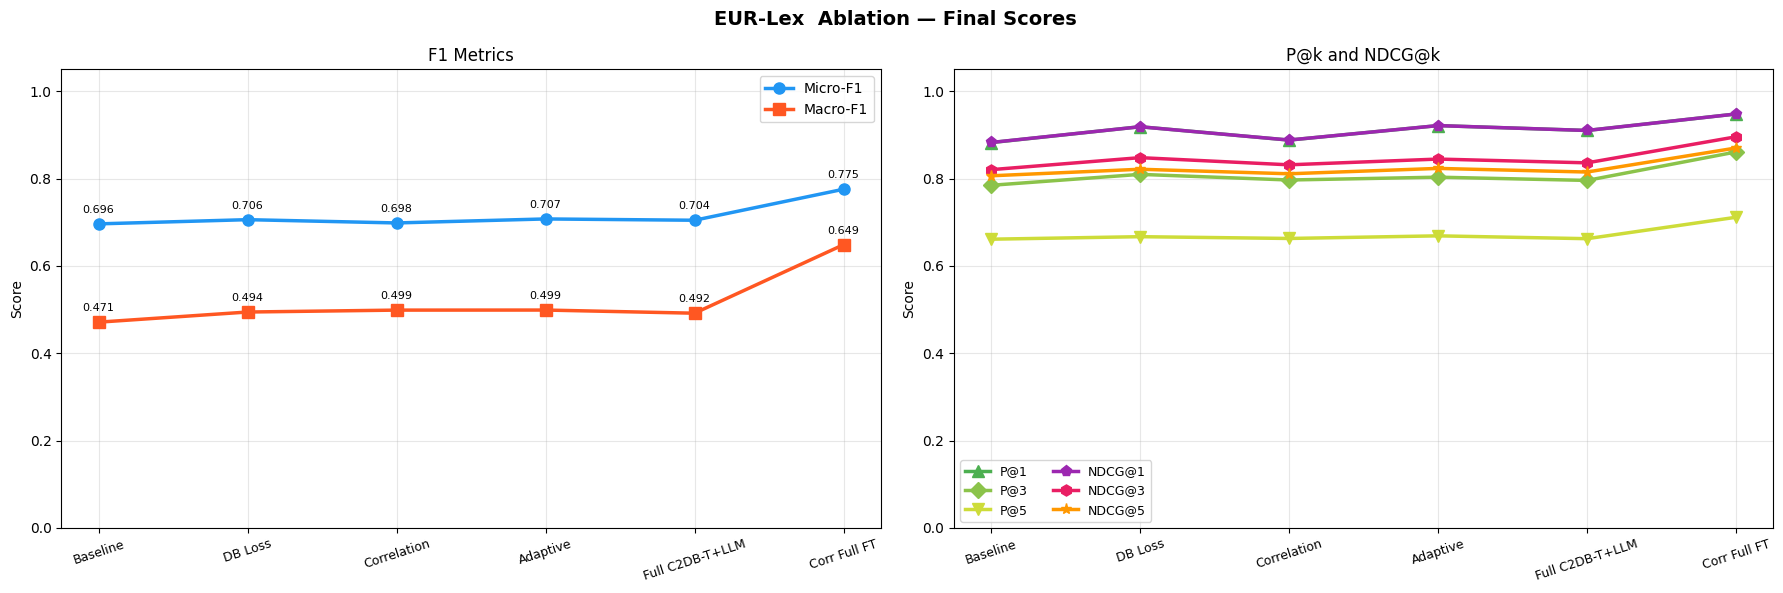

✅ Figure 2 saved: ablation_line_charts.png


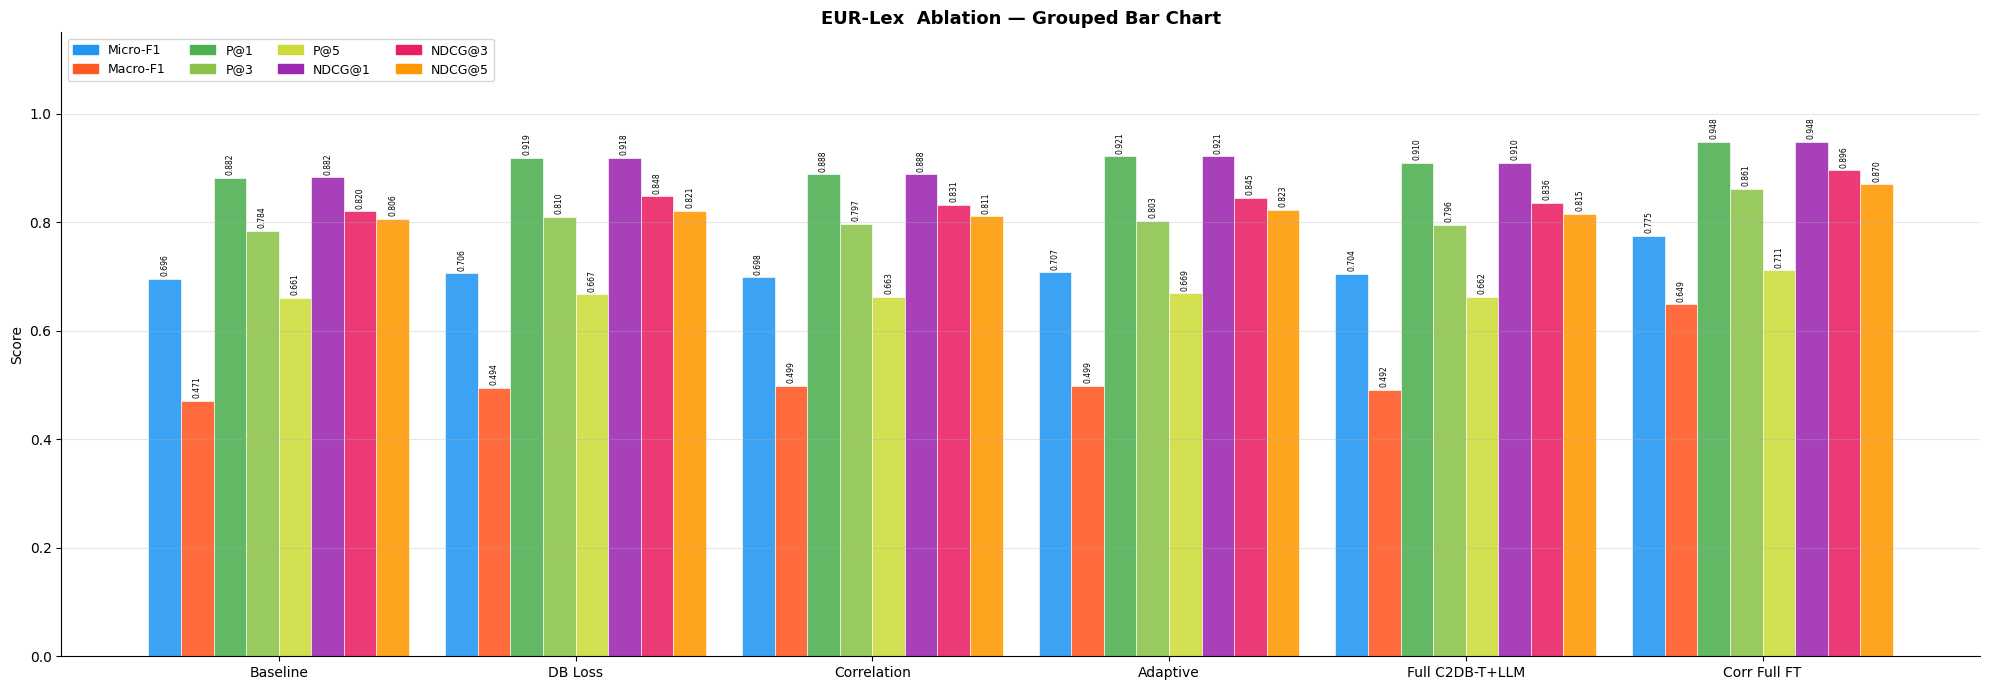

✅ Figure 3 saved: ablation_bar_chart.png


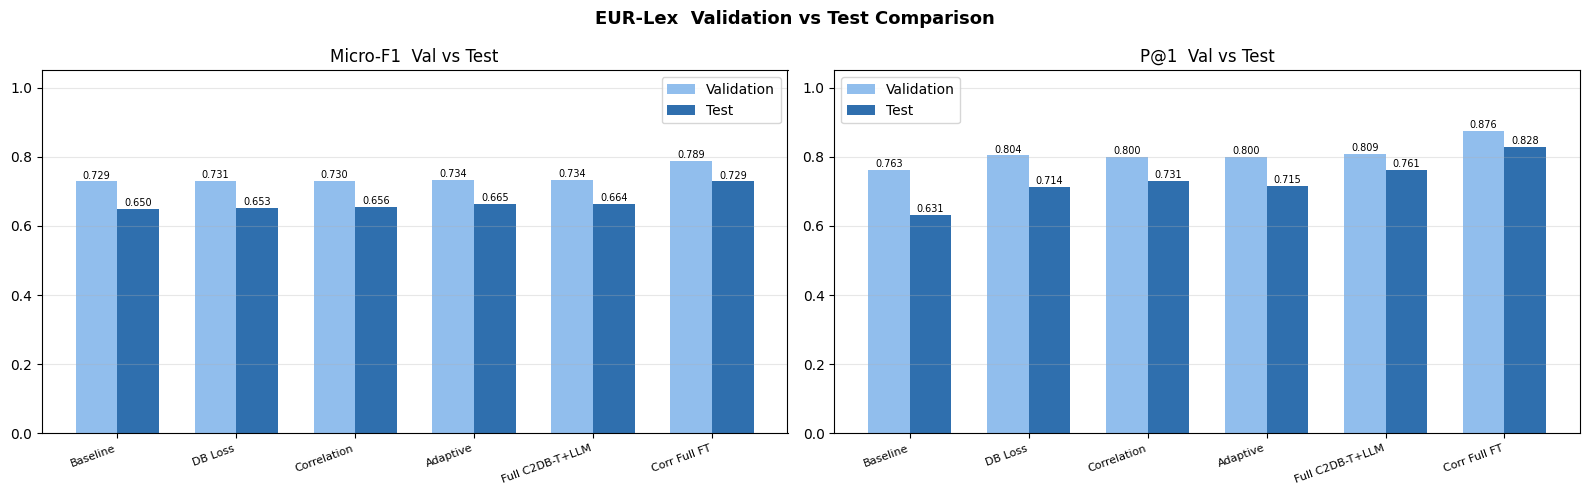

✅ Figure 4 saved: val_vs_test_comparison.png


In [15]:
# ══════════════════════════════════════════════════════════════════
# CELL 14 — PLOTS: Line charts + Bar chart + Training curves + Val vs Test
# ══════════════════════════════════════════════════════════════════

STEPS       = STEPS_ALL
all_hist_list = [baseline_hist, db_hist, corr_hist, adapt_hist, full_hist, full_ft_hist]

def last(hist, key): return hist[key][-1]
final_scores = {k: [last(h, k) for h in all_hist_list] for k in METRIC_KEYS}

# ── Figure 1: Training curves (all metrics, all 6 models) ─────────
plt.figure(figsize=(20, 14))
for i, metric in enumerate(METRIC_KEYS):
    plt.subplot(2, 4, i+1)
    for model_name, hist in zip(STEPS, all_hist_list):
        values = hist[metric]
        plt.plot(range(1, len(values)+1), values, marker='o', label=model_name)
    plt.title(metric); plt.xlabel('Epoch'); plt.ylabel(metric)
    plt.grid(True, alpha=0.3); plt.legend(fontsize=6)
plt.suptitle('EUR-Lex  Ablation Study — All Metrics per Epoch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/training_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved: training_curves_all.png")

# ── Figure 2: Line chart (final scores) ───────────────────────────
COLORS  = {'Micro-F1':'#2196F3','Macro-F1':'#FF5722','P@1':'#4CAF50','P@3':'#8BC34A',
           'P@5':'#CDDC39','NDCG@1':'#9C27B0','NDCG@3':'#E91E63','NDCG@5':'#FF9800'}
MARKERS = {'Micro-F1':'o','Macro-F1':'s','P@1':'^','P@3':'D','P@5':'v',
           'NDCG@1':'p','NDCG@3':'h','NDCG@5':'*'}
x = list(range(len(STEPS)))
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('EUR-Lex  Ablation — Final Scores', fontsize=14, fontweight='bold')
for k in ['Micro-F1', 'Macro-F1']:
    axes[0].plot(x, final_scores[k], marker=MARKERS[k], color=COLORS[k],
                 linewidth=2.5, markersize=8, label=k)
    for xi, yi in zip(x, final_scores[k]):
        axes[0].annotate(f'{yi:.3f}', xy=(xi, yi), xytext=(0,8),
                         textcoords='offset points', ha='center', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(STEPS, rotation=18, fontsize=9)
axes[0].set_ylabel('Score'); axes[0].set_title('F1 Metrics')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1.05)
for k in ['P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']:
    axes[1].plot(x, final_scores[k], marker=MARKERS[k], color=COLORS[k],
                 linewidth=2.5, markersize=8, label=k)
axes[1].set_xticks(x); axes[1].set_xticklabels(STEPS, rotation=18, fontsize=9)
axes[1].set_ylabel('Score'); axes[1].set_title('P@k and NDCG@k')
axes[1].legend(fontsize=9, ncol=2); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/ablation_line_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved: ablation_line_charts.png")

# ── Figure 3: Grouped Bar Chart ───────────────────────────────────
BAR_COLORS = ['#2196F3','#FF5722','#4CAF50','#8BC34A','#CDDC39','#9C27B0','#E91E63','#FF9800']
n_steps = len(STEPS); n_metrics = len(METRIC_KEYS)
bar_width = 0.09; group_gap = 0.10
group_width   = n_metrics * bar_width + group_gap
group_centers = np.arange(n_steps) * group_width
fig, ax = plt.subplots(figsize=(20, 7))
for mi, (metric, color) in enumerate(zip(METRIC_KEYS, BAR_COLORS)):
    offsets = group_centers + (mi - n_metrics / 2 + 0.5) * bar_width
    bars = ax.bar(offsets, final_scores[metric], width=bar_width, color=color,
                  label=metric, alpha=0.88, edgecolor='white', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h+0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=5.5, rotation=90)
ax.set_xticks(group_centers); ax.set_xticklabels(STEPS, fontsize=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title('EUR-Lex  Ablation — Grouped Bar Chart', fontsize=13, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=c, label=k) for k, c in zip(METRIC_KEYS, BAR_COLORS)],
          fontsize=9, ncol=4, loc='upper left')
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/ablation_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved: ablation_bar_chart.png")

# ── Figure 4: Val vs Test Comparison ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(STEPS)); w = 0.35
for ax, metric in zip(axes, ['Micro-F1', 'P@1']):
    val_v  = [tuned_results.get(s, {}).get(metric, 0) for s in STEPS]
    test_v = [test_results.get(s,  {}).get(metric, 0) for s in STEPS]
    ax.bar(x-w/2, val_v,  w, label='Validation', color='#85B7EB', alpha=0.9)
    ax.bar(x+w/2, test_v, w, label='Test',        color='#185FA5', alpha=0.9)
    for xi, (v, t) in enumerate(zip(val_v, test_v)):
        ax.text(xi-w/2, v+0.002, f'{v:.3f}', ha='center', fontsize=7, va='bottom')
        ax.text(xi+w/2, t+0.002, f'{t:.3f}', ha='center', fontsize=7, va='bottom')
    ax.set_xticks(x); ax.set_xticklabels(STEPS, rotation=20, ha='right', fontsize=8)
    ax.set_title(f'{metric}  Val vs Test')
    ax.legend(); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1.05)
plt.suptitle('EUR-Lex  Validation vs Test Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/val_vs_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved: val_vs_test_comparison.png")

In [16]:
# ══════════════════════════════════════════════════════════════════
# CELL 15 — FINAL SUMMARY: List all saved Drive files
# ══════════════════════════════════════════════════════════════════
import os

print("\n" + "═"*60)
print("✅ ALL FILES SAVED IN GOOGLE DRIVE")
print(f"   📁 {WORK_DIR}")
print("═"*60)

for f in sorted(WORK_DIR.iterdir()):
    size_mb = os.path.getsize(f) / (1024**2)
    print(f"  📄 {f.name:<45} {size_mb:>7.2f} MB")

print("═"*60)
print()
print("Summary of key result files:")
print("  val_histories_steps1_5.json   → val metrics per epoch (Steps 1-5)")
print("  val_history_step6_full_ft.json→ val metrics per epoch (Step 6)")
print("  tuned_val_results.json        → val results after threshold tuning")
print("  per_label_thresholds.json     → per-label thresholds (100 values each)")
print("  test_results.json             → final TEST SET results (all 6 models)")
print("  *_best.pth                    → best model checkpoints")
print("  *.png                         → all plots")
print("  embeddings_*.pt               → RoBERTa embeddings (cached)")
print("  adj_matrix_auto.pt            → label co-occurrence matrix")
print("  pca_model.pkl                 → fitted PCA model")


════════════════════════════════════════════════════════════
✅ ALL FILES SAVED IN GOOGLE DRIVE
   📁 /content/drive/MyDrive/mlvr1_eurlex
════════════════════════════════════════════════════════════
  📄 ablation_bar_chart.png                           0.08 MB
  📄 ablation_line_charts.png                         0.12 MB
  📄 adapt_pca_best.pth                               1.24 MB
  📄 adj_matrix_auto.pt                               0.04 MB
  📄 baseline_pca_best.pth                            1.20 MB
  📄 corr_full_ft_best.pth                          477.31 MB
  📄 corr_pca_best.pth                                1.24 MB
  📄 db_pca_best.pth                                  1.20 MB
  📄 embeddings_test.pt                              14.65 MB
  📄 embeddings_train.pt                            161.13 MB
  📄 embeddings_val.pt                               14.65 MB
  📄 full_pca_best.pth                                1.24 MB
  📄 label2id.pkl                                     0.00 MB
  📄 pca_m